# 05 — Prescriptive Analytics: From Insight to Action

**Goal:** Close the analytics loop. Take the segments (notebook 02) and forecasts (notebook 03), and combine them into three concrete action lists for three specific stakeholders.

This is where data analytics earns its keep — the moment between "here's what we know" and "here's what to do."

**What this notebook produces:**

| Output | Recipient | Business question answered |
|---|---|---|
| **`marketing_allocations.csv`** | CMO (David) | How to allocate next quarter's marketing spend across customer segments and regions |
| **`inventory_recommendations.csv`** | VP Merchandising (Robert) | How much inventory to stock by product line and country for the next 6 months |
| **`maintenance_outreach.csv`** | Customer Service Director (Aisha) | Which 500 customers to prioritize for proactive maintenance outreach this quarter |

**Inputs:**
- `data/processed/fact_sales.csv` — transaction history
- `data/processed/dim_customers.csv` — customer master
- `data/processed/dim_products.csv` — product catalogue with maintenance flag
- `data/predictions/segments.csv` — RFM and K-Means segments per customer (from notebook 02)
- `data/predictions/forecasts.csv` — Prophet 6-month forecasts (from notebook 03)

**Outputs:**
- `data/predictions/marketing_allocations.csv`
- `data/predictions/inventory_recommendations.csv`
- `data/predictions/maintenance_outreach.csv`

**Design principle:** every output is something a stakeholder can act on without further analysis. No "interesting findings, here's some more to think about." Specific, ranked, justified action items.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titleweight'] = 'bold'

DATA_DIR = Path('../data/processed')
PRED_DIR = Path('../data/predictions')

# Reference date matches what was used in notebooks 02/03
TODAY = pd.Timestamp('2014-01-01')   # last full month + 1 day
print(f'Reference date for "today": {TODAY.date()}')
print(f'Forecast horizon: 6 months (Jan-Jun 2014)')


Reference date for "today": 2014-01-01
Forecast horizon: 6 months (Jan-Jun 2014)


## 2. Load All Inputs

In [2]:
# Customer master + segments
customers = pd.read_csv(DATA_DIR / 'dim_customers.csv')
segments = pd.read_csv(PRED_DIR / 'segments.csv')

# Join customer info with segments
customers = customers.merge(segments, on='customer_key', how='left')
print(f'Customers with segments: {customers["RFM_Segment"].notna().sum():,} / {len(customers):,}')

# Transaction history (for last-purchase logic)
fact = pd.read_csv(DATA_DIR / 'fact_sales.csv', parse_dates=['order_date'])
fact = fact.dropna(subset=['order_date'])

# Products with maintenance flag
products = pd.read_csv(DATA_DIR / 'dim_products.csv')

# Forecasts from Prophet
forecasts = pd.read_csv(PRED_DIR / 'forecasts.csv', parse_dates=['month'])
print(f'Forecast rows: {len(forecasts):,}')
print(f'Forecast horizon: {forecasts["month"].min().date()} → {forecasts["month"].max().date()}')


Customers with segments: 18,482 / 18,484
Forecast rows: 72
Forecast horizon: 2014-01-01 → 2014-06-01


## 3. Marketing Spend Allocation

**Recipient:** CMO (David)

**Question:** *"Where do I put next quarter's marketing budget?"*

**Logic:** Distribute marketing spend in proportion to the **opportunity value** of each (segment x country) combination. Opportunity value = current segment revenue contribution x expected growth from the Prophet forecast.

The four RFM segments have very different marketing payoffs:
- **Whales** — retention spend (small audience, high LTV)
- **Everyday** — cross-sell spend (large audience, moderate value)
- **At Risk** — win-back spend (medium audience, fading value)
- **New Passions** — acquisition spend (small but growing)

We blend these segment characteristics with the country forecast to allocate a hypothetical \$1M quarterly budget.


In [3]:
# Step 1: enrich fact_sales with customer's country and segment
fact_enriched = fact.merge(
    customers[['customer_key', 'country', 'RFM_Segment']],
    on='customer_key', how='left'
)

# Step 2: compute current revenue by segment x country
revenue_by_seg_country = (
    fact_enriched.groupby(['country', 'RFM_Segment'])
    .agg(historical_revenue=('sales_amount', 'sum'),
         customers=('customer_key', 'nunique'))
    .reset_index()
)
revenue_by_seg_country = revenue_by_seg_country[revenue_by_seg_country['RFM_Segment'].notna()]
print(f'Segment x country combinations: {len(revenue_by_seg_country)}')
print()
print(revenue_by_seg_country.head(10))


Segment x country combinations: 24

     country   RFM_Segment  historical_revenue  customers
0  Australia       At Risk             3327602       1152
1  Australia      Everyday             2501491       1153
2  Australia  New Passions               11713         66
3  Australia        Whales             3219339       1220
4     Canada       At Risk              552294        380
5     Canada      Everyday              756086        608
6     Canada  New Passions               14513         38
7     Canada        Whales              654840        545
8     France       At Risk              735160        587
9     France      Everyday              793953        735


In [4]:
# Step 3: compute forecasted growth per country (sum across product lines)
forecast_by_country = (
    forecasts.groupby('country')
    .agg(forecast_revenue_6mo=('forecast', 'sum'))
    .reset_index()
)

# Recent historical revenue (last 6 months of history) by country, for growth ratio
recent_history_start = pd.Timestamp('2013-07-01')
recent_revenue_by_country = (
    fact_enriched[fact_enriched['order_date'] >= recent_history_start]
    .groupby('country')['sales_amount'].sum()
    .reset_index()
    .rename(columns={'sales_amount': 'recent_6mo_revenue'})
)

country_growth = forecast_by_country.merge(recent_revenue_by_country, on='country', how='inner')
country_growth['growth_ratio'] = country_growth['forecast_revenue_6mo'] / country_growth['recent_6mo_revenue']
country_growth = country_growth.sort_values('growth_ratio', ascending=False)
print('Country-level growth signal (forecast vs recent history):')
print(country_growth.round(2))


Country-level growth signal (forecast vs recent history):
          country  forecast_revenue_6mo  recent_6mo_revenue  growth_ratio
4  United Kingdom             946020.15             1199871          0.79
2          France             695484.19              918968          0.76
3         Germany             722680.32             1075583          0.67
0       Australia            1633444.69             2552461          0.64
5   United States            1952594.54             3132841          0.62
1          Canada             320775.81              673398          0.48


In [5]:
# Step 4: combine segment value with country growth to get opportunity score
opportunity = revenue_by_seg_country.merge(
    country_growth[['country', 'growth_ratio']], on='country', how='left'
)

# Segment weights reflect marketing payoff per dollar
SEGMENT_WEIGHTS = {
    'Whales': 1.5,        # high LTV, retention spend pays off most
    'New Passions': 1.3,  # growth segment, acquisition important
    'At Risk': 1.0,       # win-back spend has moderate ROI
    'Everyday': 0.7,      # large but lower value per customer
}
opportunity['segment_weight'] = opportunity['RFM_Segment'].map(SEGMENT_WEIGHTS)

# Opportunity score = historical revenue x growth potential x segment weight
opportunity['opportunity_score'] = (
    opportunity['historical_revenue']
    * opportunity['growth_ratio'].fillna(1)
    * opportunity['segment_weight']
)

# Normalize to allocate a budget
BUDGET = 1_000_000  # quarterly marketing budget assumed
total_score = opportunity['opportunity_score'].sum()
opportunity['allocation_pct'] = opportunity['opportunity_score'] / total_score
opportunity['allocation_usd'] = opportunity['allocation_pct'] * BUDGET

# Format outputs
marketing_alloc = (
    opportunity[['country', 'RFM_Segment', 'customers',
                 'historical_revenue', 'growth_ratio', 'segment_weight',
                 'opportunity_score', 'allocation_pct', 'allocation_usd']]
    .sort_values('allocation_usd', ascending=False)
    .reset_index(drop=True)
)
print(f'Allocation total: \${marketing_alloc["allocation_usd"].sum():,.0f}')
print()
print(marketing_alloc.head(10).round(2))


Allocation total: \$1,000,000

          country RFM_Segment  customers  historical_revenue  growth_ratio  segment_weight  opportunity_score  allocation_pct  allocation_usd
0       Australia      Whales       1220             3219339          0.64             1.5         3090318.83            0.15       149980.68
1   United States      Whales       1541             2288244          0.62             1.5         2139278.41            0.10       103824.38
2   United States     At Risk       2589             3431066          0.62             1.0         2138468.16            0.10       103785.05
3       Australia     At Risk       1152             3327602          0.64             1.0         2129495.34            0.10       103349.58
4  United Kingdom      Whales        584             1391914          0.79             1.5         1646150.32            0.08        79891.67
5   United States    Everyday       2966             3301887          0.62             0.7         1440568.66        

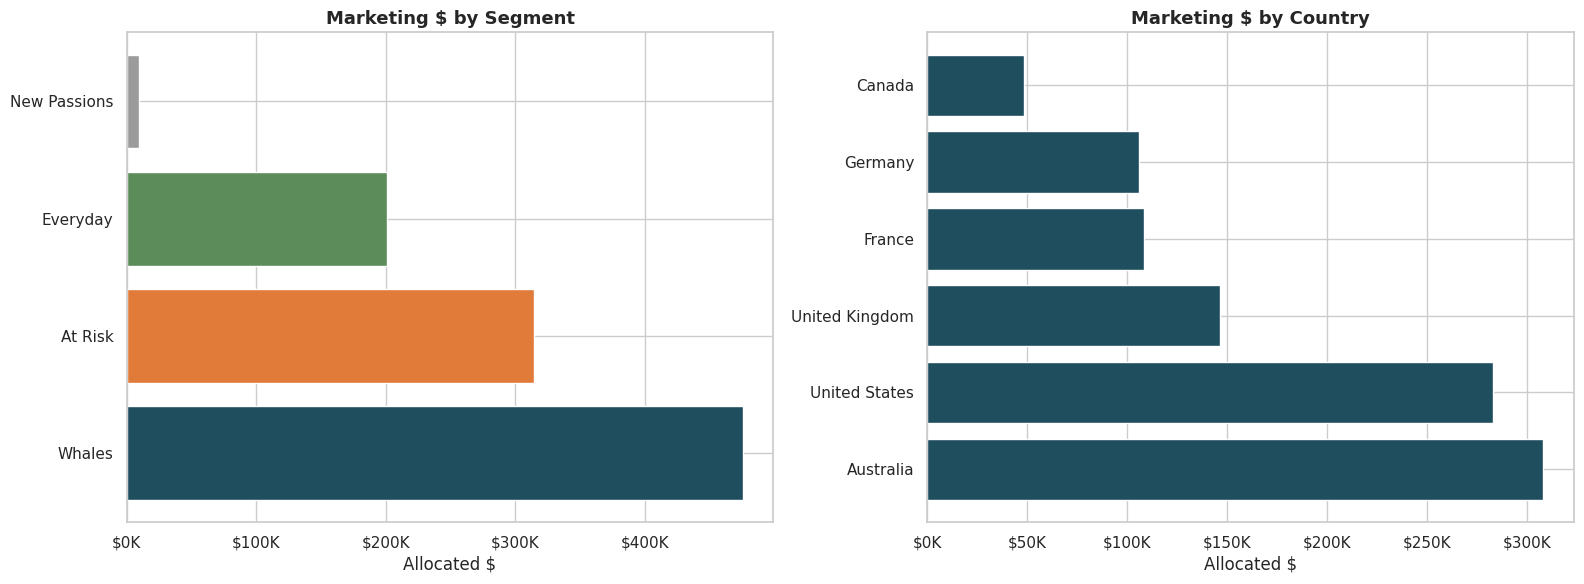

In [6]:
# Visualize the allocation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Allocation by segment
by_seg = marketing_alloc.groupby('RFM_Segment')['allocation_usd'].sum().sort_values(ascending=False)
seg_palette = {'Whales': '#1F4E5F', 'Everyday': '#5B8C5A',
               'At Risk': '#E07B39', 'New Passions': '#9B9B9B'}
colors_seg = [seg_palette.get(s, '#888') for s in by_seg.index]
axes[0].barh(by_seg.index, by_seg.values, color=colors_seg)
axes[0].set_title('Marketing $ by Segment', fontsize=13)
axes[0].set_xlabel('Allocated $')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e3:.0f}K'))

# Allocation by country
by_ctry = marketing_alloc.groupby('country')['allocation_usd'].sum().sort_values(ascending=False)
axes[1].barh(by_ctry.index, by_ctry.values, color='#1F4E5F')
axes[1].set_title('Marketing $ by Country', fontsize=13)
axes[1].set_xlabel('Allocated $')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'\${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()


**How to read the allocation:**
- The CMO can use the table as-is: each row is one specific "spend X dollars on Y segment in Z country" line item.
- The `growth_ratio` column shows where the forecast says future revenue is expected vs. recent history. Ratios > 1 = growth.
- The `segment_weight` reflects marketing ROI judgments by segment type. These weights are configurable — if the CMO disagrees with the heuristics, change them and re-run.


## 4. Inventory Recommendations

**Recipient:** VP Merchandising (Robert)

**Question:** *"How much inventory should I stock by product line and country for the next 6 months?"*

**Logic:** Use the Prophet forecast directly. For each (product_line x country) combination, multiply the forecasted revenue by:
1. **Historical units per dollar** — derived from past sales, to convert revenue forecast to unit forecast
2. **Safety stock factor** — multiply by 1.2x to handle the wide forecast confidence intervals

We also flag the upper confidence interval so Robert knows the worst-case demand to plan against.


In [7]:
# Step 1: historical units per dollar by product_line x country
hist = (
    fact_enriched
    .merge(products[['product_key', 'product_line']], on='product_key', how='left', suffixes=('_x', ''))
    .groupby(['product_line', 'country'])
    .agg(historical_revenue=('sales_amount', 'sum'),
         historical_units=('quantity', 'sum'))
    .reset_index()
)
hist['units_per_dollar'] = hist['historical_units'] / hist['historical_revenue']

# Step 2: forecast revenue x units_per_dollar = forecasted units
inv = forecasts.merge(hist[['product_line', 'country', 'units_per_dollar']],
                      on=['product_line', 'country'], how='inner')
inv['forecast_units'] = inv['forecast'] * inv['units_per_dollar']
inv['forecast_units_upper'] = inv['yhat_upper'] * inv['units_per_dollar']

# Step 3: aggregate 6 months ahead per product_line x country
inventory_rec = (
    inv.groupby(['product_line', 'country'])
    .agg(forecast_revenue_6mo=('forecast', 'sum'),
         forecast_units_6mo=('forecast_units', 'sum'),
         forecast_units_upper_6mo=('forecast_units_upper', 'sum'))
    .reset_index()
)
SAFETY_STOCK = 1.2
inventory_rec['recommended_units_6mo'] = (inventory_rec['forecast_units_6mo'] * SAFETY_STOCK).round(0).astype(int)
inventory_rec['stretch_units_6mo'] = inventory_rec['forecast_units_upper_6mo'].round(0).astype(int)

inventory_rec = inventory_rec.sort_values('forecast_revenue_6mo', ascending=False).reset_index(drop=True)
print(f'Inventory rows: {len(inventory_rec)} (one per product_line x country)')
print(inventory_rec.head(12).round(0))


Inventory rows: 12 (one per product_line x country)
   product_line         country  forecast_revenue_6mo  forecast_units_6mo  forecast_units_upper_6mo  recommended_units_6mo  stretch_units_6mo
0      Mountain   United States             1588554.0              3015.0                    3599.0                   3618               3599
1          Road       Australia              920450.0               804.0                    1042.0                    964               1042
2      Mountain       Australia              712995.0               809.0                     987.0                    971                987
3      Mountain  United Kingdom              535936.0               703.0                     846.0                    844                846
4      Mountain         Germany              456804.0               589.0                     722.0                    707                722
5      Mountain          France              412147.0               537.0                     63

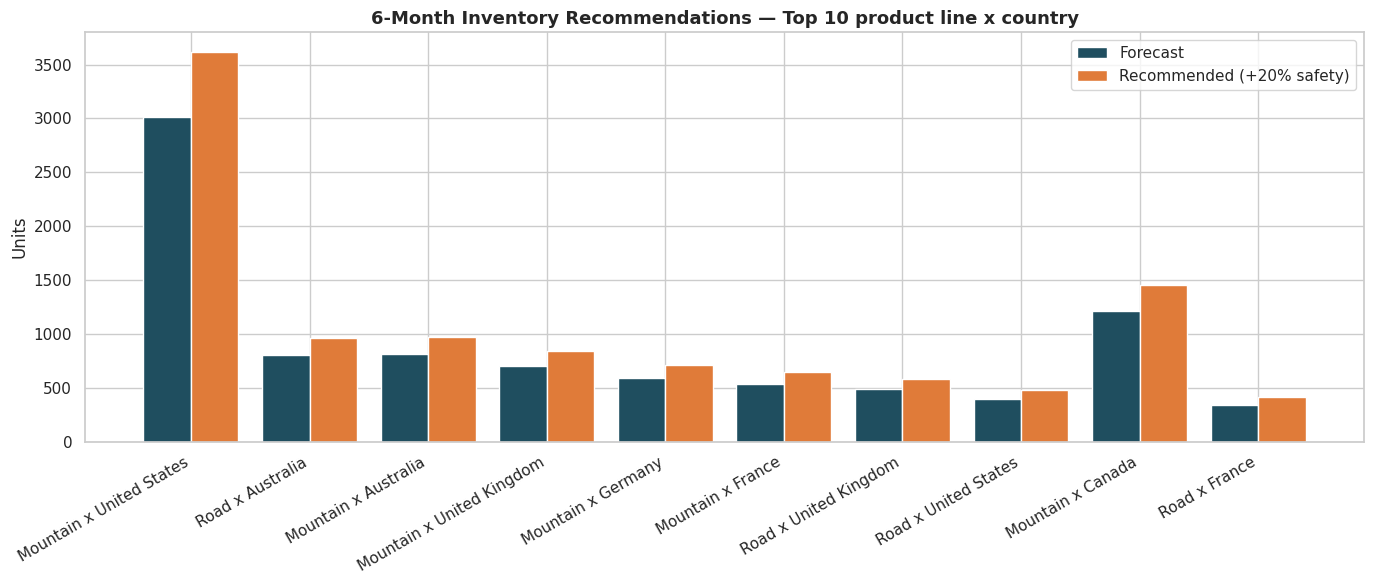

In [8]:
# Visualize: recommended units for top combinations
fig, ax = plt.subplots(figsize=(14, 6))
top = inventory_rec.head(10).copy()
top['label'] = top['product_line'] + ' x ' + top['country']
x_pos = np.arange(len(top))

ax.bar(x_pos - 0.2, top['forecast_units_6mo'], 0.4, label='Forecast', color='#1F4E5F')
ax.bar(x_pos + 0.2, top['recommended_units_6mo'], 0.4, label='Recommended (+20% safety)', color='#E07B39')
ax.set_xticks(x_pos)
ax.set_xticklabels(top['label'], rotation=30, ha='right')
ax.set_ylabel('Units')
ax.set_title('6-Month Inventory Recommendations — Top 10 product line x country', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Maintenance Outreach List

**Recipient:** Customer Service Director (Aisha)

**Question:** *"Which customers should the service team call this quarter for proactive maintenance outreach?"*

**Logic:** Identify customers who:
1. **Own at least one maintenance-eligible product** (`dim_products.maintenance = "Yes"`)
2. **Haven't transacted in 90+ days** (potentially needing service follow-up)
3. **Are valuable enough to justify outreach time** (segment value)

Rank them by an outreach priority score that combines segment value, days since last contact, and maintenance product ownership.


In [9]:
# Step 1: find customers who own at least one maintenance-eligible product
maintenance_products = products[products['maintenance'] == 'Yes']['product_key'].tolist()
print(f'Maintenance-eligible products: {len(maintenance_products)}')

# Customers who have ever bought a maintenance product
maintenance_customers = (
    fact_enriched[fact_enriched['product_key'].isin(maintenance_products)]
    .groupby('customer_key')
    .agg(maintenance_products_owned=('product_key', 'nunique'),
         maintenance_orders=('order_number', 'nunique'))
    .reset_index()
)
print(f'Customers with maintenance products: {len(maintenance_customers):,}')


Maintenance-eligible products: 226
Customers with maintenance products: 16,316


In [10]:
# Step 2: compute days since last purchase per customer
last_purchase = (
    fact_enriched.groupby('customer_key')['order_date'].max().reset_index()
    .rename(columns={'order_date': 'last_purchase_date'})
)
last_purchase['days_since_last_purchase'] = (TODAY - last_purchase['last_purchase_date']).dt.days

# Combine with segments and maintenance ownership
outreach = (
    maintenance_customers
    .merge(last_purchase, on='customer_key', how='left')
    .merge(customers[['customer_key', 'first_name', 'last_name', 'country',
                      'RFM_Segment', 'Recency', 'Frequency', 'Monetary']],
           on='customer_key', how='left')
)

# Step 3: filter to customers who haven't bought in 90+ days
outreach_eligible = outreach[outreach['days_since_last_purchase'] >= 90].copy()
print(f'Customers eligible for outreach: {len(outreach_eligible):,}')
print(f'  ({len(outreach_eligible) / len(maintenance_customers) * 100:.1f}% of maintenance customers)')


Customers eligible for outreach: 10,494
  (64.3% of maintenance customers)


In [11]:
# Step 4: compute priority score
# Outreach Priority = segment_value * maintenance_products_owned * (days_since/365)
SEGMENT_OUTREACH_VALUE = {
    'Whales': 1.0,
    'New Passions': 0.8,
    'At Risk': 0.6,
    'Everyday': 0.4,
}
outreach_eligible['segment_value'] = outreach_eligible['RFM_Segment'].map(SEGMENT_OUTREACH_VALUE).fillna(0.3)
outreach_eligible['recency_factor'] = (outreach_eligible['days_since_last_purchase'] / 365).clip(upper=2.0)
outreach_eligible['outreach_priority'] = (
    outreach_eligible['segment_value']
    * outreach_eligible['maintenance_products_owned']
    * outreach_eligible['recency_factor']
    * np.log1p(outreach_eligible['Monetary'])
)

# Rank
outreach_ranked = outreach_eligible.sort_values('outreach_priority', ascending=False).reset_index(drop=True)
outreach_ranked['rank'] = outreach_ranked.index + 1

# Keep top 500
TOP_N = 500
top_outreach = outreach_ranked.head(TOP_N)
print(f'Top {TOP_N} outreach customers ranked.')
print()
print(top_outreach[['rank', 'first_name', 'last_name', 'country', 'RFM_Segment',
                    'maintenance_products_owned', 'days_since_last_purchase',
                    'Monetary', 'outreach_priority']].head(15).round(2))


Top 500 outreach customers ranked.

    rank first_name  last_name         country RFM_Segment  maintenance_products_owned  days_since_last_purchase  Monetary  outreach_priority
0      1      Marco      Mehta       Australia     At Risk                           7                       288    8211.0              29.87
1      2      Ethan    Coleman       Australia     At Risk                           5                       363    6060.0              25.99
2      3     Latoya       Goel  United Kingdom     At Risk                           8                       218    7511.0              25.58
3      4     Taylor      Lewis   United States     At Risk                           5                       357    6058.0              25.56
4      5     Ronald       Suri       Australia     At Risk                           5                       355    6093.0              25.43
5      6     Willie       Raji       Australia     At Risk                           9                       189

Top 500 outreach customers by segment x country:
country      Australia  Canada  France  Germany  United Kingdom  United States
RFM_Segment                                                                   
At Risk            145      29      46       45              72            143
Everyday             0       0       0        1               1              0
Whales               7       1       6        2               1              0


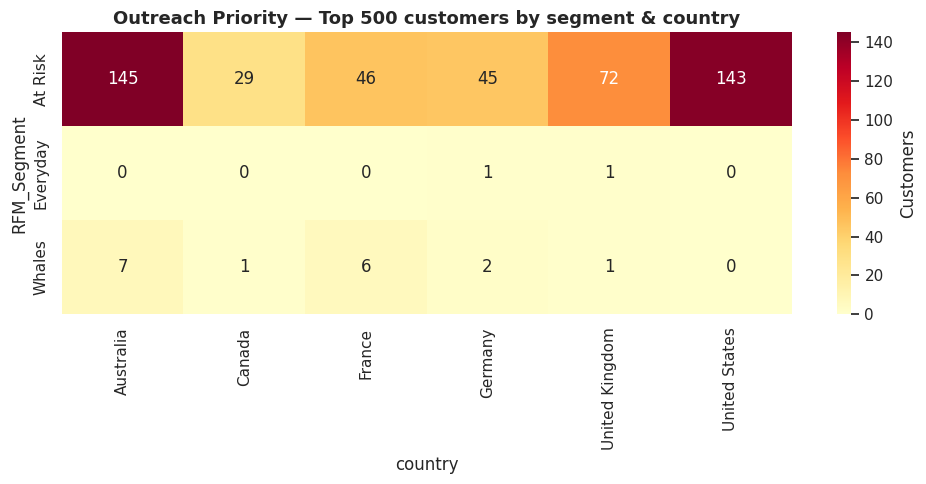

In [12]:
# Visualize: top 500 outreach customers by segment x country
top_summary = (
    top_outreach.groupby(['RFM_Segment', 'country']).size().reset_index(name='customers')
    .pivot(index='RFM_Segment', columns='country', values='customers').fillna(0).astype(int)
)
print('Top 500 outreach customers by segment x country:')
print(top_summary)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(top_summary, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Customers'}, ax=ax)
ax.set_title(f'Outreach Priority — Top {TOP_N} customers by segment & country', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Save All Three Action Lists

In [13]:
# 1. Marketing allocations
marketing_alloc.to_csv(PRED_DIR / 'marketing_allocations.csv', index=False)
print(f'Saved: marketing_allocations.csv ({len(marketing_alloc)} rows)')

# 2. Inventory recommendations
inventory_rec.to_csv(PRED_DIR / 'inventory_recommendations.csv', index=False)
print(f'Saved: inventory_recommendations.csv ({len(inventory_rec)} rows)')

# 3. Maintenance outreach (top 500)
top_outreach.to_csv(PRED_DIR / 'maintenance_outreach.csv', index=False)
print(f'Saved: maintenance_outreach.csv (top {TOP_N} of {len(outreach_ranked)} eligible)')


Saved: marketing_allocations.csv (24 rows)
Saved: inventory_recommendations.csv (12 rows)
Saved: maintenance_outreach.csv (top 500 of 10494 eligible)


## 7. Conclusions

### What This Notebook Delivered

| File | For | Concrete action it enables |
|---|---|---|
| `marketing_allocations.csv` | CMO | Pre-built quarterly budget split with rationale per line |
| `inventory_recommendations.csv` | VP Merchandising | 6-month unit forecast by product line and country with safety stock |
| `maintenance_outreach.csv` | Customer Service | Ranked list of 500 customers to call this quarter |

Each output is built so the recipient can act on it without further analysis. The fields are named in business terms, the rationale is documented in the calculation, and the rankings are quantitative.

### What Makes This a Real Prescriptive Layer

A common mistake in portfolio projects is to build a predictive model and stop. The model says "customer X has a 70% probability of churn" — but **so what?** The CMO doesn't act on a probability; she acts on a list of customers to call, ranked by expected impact.

This notebook performs the *last mile* of analytics: turning model outputs into ranked, named, justified action items.

### How It Connects to the Earlier Phases

- **Phase 1 (data warehouse)** built the gold layer that everything reads from.
- **Phase 2 (Power BI)** answers "what is happening?" — the descriptive layer.
- **Phase 3 (ML)** answered "what will happen?" with forecasts and "who are our customers?" with segments.
- **This notebook** answers "what should we do about it?" — the prescriptive layer.

That progression — descriptive → diagnostic → predictive → prescriptive — is the full analytics maturity arc. Many portfolios stop at predictive. This one doesn't.

### Honest Limitations

1. **Heuristic weights.** The segment weights (1.5 for Whales, 1.3 for New Passions, etc.) reflect general marketing wisdom but are not derived from this specific data. A real implementation would test multiple weightings against marketing campaign outcomes and tune.

2. **No A/B testing framework.** The recommendations are "best-guess optimal" but unproven on this business. A real production system would log which customers were contacted, measure response, and feed those results back into the weights.

3. **6-month horizon.** Marketing and inventory cycles often differ — inventory needs 3-month and 6-month projections; marketing needs quarterly. A more polished version would expose multiple time windows.

4. **Forecast wide intervals.** The Prophet forecasts have wide confidence intervals on this small dataset. Don't treat the point estimates as commitments — use them for relative comparisons across segments and regions.

### Phase 3 Is Complete

Five notebooks across Phase 3:

1. ✅ `01_eda.ipynb` — Exploratory data analysis
2. ✅ `02_segmentation.ipynb` — RFM vs K-Means comparison
3. ✅ `03_forecasting_baseline.ipynb` — Naive + Prophet
4. ✅ `04_forecasting_lstm.ipynb` — PyTorch LSTM
5. ✅ `05_prescriptive.ipynb` — This notebook — action lists

### What's Next — Phase 4 (Production Deployment)

The notebooks are how analysts work. The API is how engineers consume the work. Phase 4 wraps the trained models in a FastAPI service so other applications can call them:

- `POST /predict/segment` — given a customer_key, return RFM and K-Means assignments
- `POST /predict/forecast` — given product_line + country + horizon, return revenue forecast
- `GET /health` — service health check
- `GET /metrics` — Prometheus metrics for monitoring

Plus Docker, docker-compose with Postgres + API + Prometheus + Grafana, GitHub Actions CI/CD. That's the production deployment layer.
